# Generation of collision-free tarjectories

To plan a robot's motion in an environment with obstacles, it is necessary to find a path from the starting point to the endpoint that avoids all contact between the robot and the obstacles. A prerequisite for path planning is knowledge of the environment. This requires accurate modeling of the geometry of objects in the workspace, including the robot and any obstacles. 

The motion is executed on the target robot, but for generation we use digital twin, i.e. a robot in MuJoCo simulation environment. 

# Imports

In [1]:
# plan_mjcf_with_ompl.py
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from time import sleep, time
from copy import copy
import mediapy as media
from pathlib import Path

import mujoco

from robotblockset.tools import get_rbs_path, print_xml
from robotblockset.mujoco.robots_mujoco import ur10e
from robotblockset.mujoco.tools_pymujoco import check_path_for_collisions, make_free_camera, check_collisions, get_robot_joints_data, get_geoms_of_body
# from robotblockset.mujoco.ompl_pymujoco import plan_robot_motion, set_optimizing_planner
from robotblockset.transformations import map_pose, rot_x, rot_y, rot_z, rp2t, xerr
from robotblockset.optimal import path_constraints, path_kinematics, timeopt_joint_traj

np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Helper function for capturing robot states

The following function stores robot time, joint states, task-space states, and commanded references during motion. These recorded arrays are later used for plotting.


Capture measured and commanded robot states into global arrays for later plotting.

In [ ]:
it = 0
def CaptureRobot_v(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtw, vtw, rxtw, rvtw, rrxtw, rrvtw, rTbt, tc, frames, tframes, last_time, framerate
    # if r.t - last_time >= 1/framerate:
    #     last_time = r.t
    #     pixels = r.scene.mj_capture_camera(width=640, height=480)
    #     frames.append(pixels)
    #     tframes.append(r.t)
        
    if it == 0:
        tt = np.array(r.t)
        twall = time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
        xtw = r.x
        vtw = r.v
        rxtw = r.x_ref
        rvtw = r.v_ref
        rrxtw = r._command.rx
        rrvtw = r._command.rv
        rTbt = r.GetBasePose(out="x")
        tc = r._last_control_time
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.v))
        rxtw = np.vstack((rxtw, r.x_ref))
        rvtw = np.vstack((rvtw, r.v_ref))
        rrxtw = np.vstack((rrxtw, r._command.rx))
        rrvtw = np.vstack((rrvtw, r._command.rv))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))
        tc = np.vstack((tc, r._last_control_time))

    it += 1


# Prepare scene and target robot

Open MuJoCo simulator and load scene (**inspection_scene.xml**). The digital tween loads the scene form the given MJCF_PATH.

In [2]:
MJCF_PATH = get_rbs_path() + "/mujoco/mjcf_models/inspection_scene.xml"

## Define target robot

The target robot is a UR10e robot simulated in MuJoCo simulator (`simmujoco`), which is controlled as a real robot. 

In [3]:
from robotblockset.mujoco.robots_mujoco import ur10e as ur10e_real
r = ur10e_real()

[RBS_INFO] [1773393951.653701544] [ur10e_MuJoCo]: Robot connected to MuJoCo


If the simulator is not available the `pymujoco` or `pymujoco_sim` can be used

In [4]:
# from robotblockset.mujoco.robots_pymujoco import mujoco_scene as scene_real, ur10e as ur10e_real
# scene_real = scene_real (MJCF_PATH, show_camera=None, verbose=1, synchronized=True)
# r = ur10e_real(scene=scene_real)

# from robotblockset.mujoco.robots_pymujoco_sim import mujoco_scene as scene_real, ur10e as ur10e_real
# scene_real = scene_real (MJCF_PATH, show_camera=None, verbose=1)
# r = ur10e_real(scene=scene_real)

In [5]:
r.Restart(keyframe=0)
r.JMove(r.q_init)

0

## Define initial and final configuration

The initial and final poses are defined using the target robot in MuJoCo simulator.

Initial pose is above the pick location (defined from model)

In [6]:
x_place = map_pose(p=r.GetObjectPose("site",  "place_surface", out="p"), R=rot_z(np.pi / 2, out="R") @ rot_y(np.pi, out="R"))

Move above the point and store configuration and define initial configuration.

In [7]:
r.CApproach(x_place, [0, -0.1, 0.15])
q_start = r.q_ref

Final pose is in front of camera (defined from model). We first get the location of  the camera

In [8]:
x_camera1 = map_pose(p=r.GetObjectPose("body",  "RS1_cam", out="p"), R=rot_y(-np.pi / 2, out="R"))

and then move to the camera in safe way and store configuration.

In [9]:
r.JMove(r.q_init)
r.Wait(1)
r.CMoveFor([-0.4, 0, 0])
r.CApproach(x_camera1, [0.15, 0, 0], t=5)
q_goal = r.q_ref

# Generate collision-free time-optimal trajectory

## Create digital twin of scene in headless mode

In [10]:
from robotblockset.mujoco.scene_pymujoco_sim import mujoco_scene
scene = mujoco_scene(str((Path.cwd() / MJCF_PATH).resolve()), show_viewer=False)
from robotblockset.mujoco.robots_pymujoco_sim import ur10e
rs = ur10e(scene=scene)

[RBS_INFO] [1773393964.346091986] [ur10e_PyMuJoCo]: Robot connected to MuJoCo


Check collisions in start and goal configuration

In [11]:
print("Collisions in start configuration:", check_path_for_collisions(q_start, rs, clearance=0.02))
print("Collisions in goal  configuration:", check_path_for_collisions(q_goal,  rs, clearance=0.02))

Collisions in start configuration: False
Collisions in goal  configuration: False


Move to start configuration

In [12]:
rs.Restart(u=q_start)
rs.JMove(q_start,1)

0

Render twin scene

""

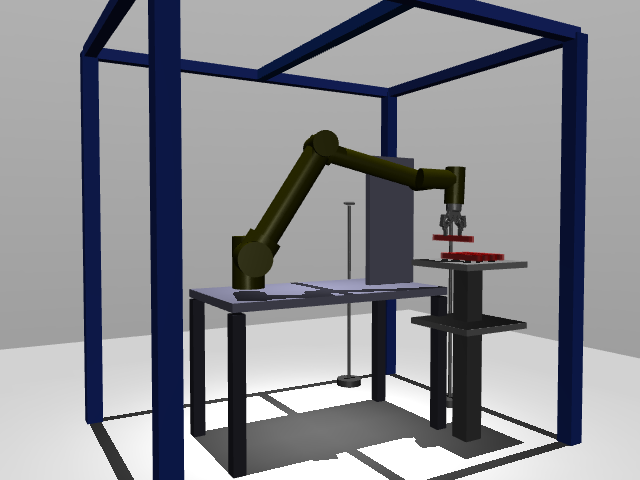

In [13]:
cam = make_free_camera(rs.scene.model, azimuth=-210, elevation=-2, distance=3.0, lookat=[0,0,1], fovy=45)
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 0, 1, 0, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
frame = scene.mj_capture_camera(camera=cam, height=480, width=640, scene_option=scene_option)
media.show_image(frame)

Move to goal configuration

In [14]:
rs.Restart(u=q_goal)
rs.JMove(q_goal,1)

0

Render twin scene

""

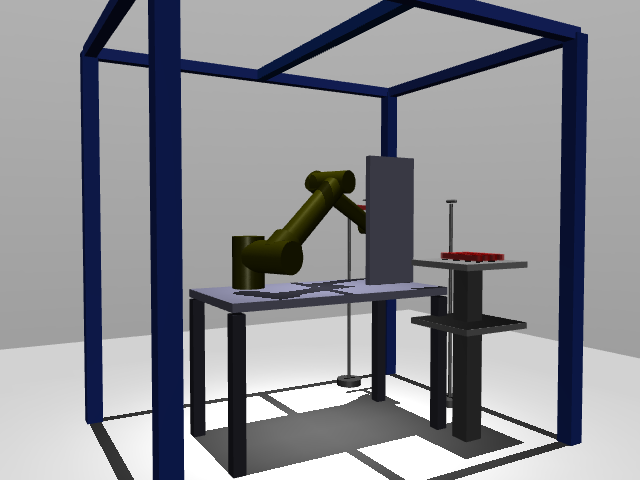

In [15]:
cam = make_free_camera(rs.scene.model, azimuth=-210, elevation=-2, distance=3.0, lookat=[0,0,1], fovy=45)
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 0, 1, 0, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
frame = scene.mj_capture_camera(camera=cam, height=480, width=640, scene_option=scene_option)
media.show_image(frame)

## Plan collision-free path

For safer movements add margin to all geoms important for motion planning

In [16]:
for bid in [scene.model.body("main_table").id, scene.model.body("cell_enclosure").id]:
    for id in get_geoms_of_body(rs.scene.model, bid):
        print(rs.scene.model.geom(id).name)
        rs.scene.model.geom(id).margin = 0.02

main_table_top
main_table_obstacle
main_table_leg_fl
main_table_leg_fr
main_table_leg_rl
main_table_leg_rr
post_fl
post_fr
post_rl
post_rr
beam_front
beam_rear
beam_left
beam_right
beam_over_robot
panel_front
panel_rear
panel_left
panel_right
panel_top


Select suitable algorithm and clearance for contacts

In [36]:
path, waypts = plan_robot_motion(rs, q_start, q_goal, algorithm="InformedRRT*", max_planning_time=10, clearance=0.01)
if path is None:
    print("No path found.")
else:
    print("Path:", path.shape)


Debug:   InformedRRTstar: Planner range detected to be 5.758630
Info:    InformedRRTstar: Using informed sampling.
Info:    InformedRRTstar: Started planning with 1 states. Seeking a solution better than 0.00000.
Info:    InformedRRTstar: Initial k-nearest value of 310
Info:    InformedRRTstar: Found an initial solution with a cost of 7.86 in 21859 iterations (356 vertices in the graph)
Info:    InformedRRTstar: Created 1109 new states. Checked 232622 rewire options. 1 goal states in tree. Final solution cost 3.819
Info:    Solution found in 10.102035 seconds
Debug:   The solution path was slightly touching on an invalid region of the state space, but it was successfully fixed.
Info:    SimpleSetup: Path simplification took 0.020719 seconds and changed from 4 to 4 states
Path: (100, 6)


Check if the calculated path starts and ends in required configurations

In [37]:
print(f"Max joint position error in start configuration: {np.max(q_start-waypts[0])}")
print(f"Max joint position error in goal  configuration: {np.max(q_goal-waypts[-1])}")

Max joint position error in start configuration: 0.0
Max joint position error in goal  configuration: 0.0


Calculated waypoints

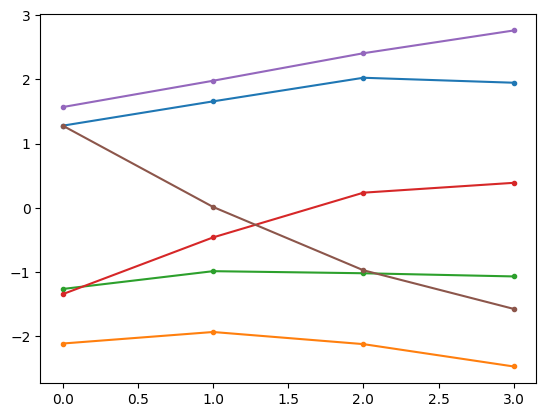

In [38]:
_ = plt.plot(waypts,".-")

In [18]:
scipy.io.savemat("assets/inspection_collision_free_path.mat", {"q_start": q_start, "q_goal":q_goal, "waypts": waypts})

## Generate time-optimal path considering kinematic constraints

In [19]:
mat = scipy.io.loadmat("assets/inspection_collision_free_path.mat")
q_start    = mat.get("q_start").flatten()
q_goal     = mat.get("q_goal").flatten()
waypts     = mat.get("waypts")

Path constraints

In [20]:
path_con = path_constraints()
# path_con.xdnmax = 1
# path_con.xddnmax = 2check_collisions
# path_con.xdmax = np.ones(6) * 1
# path_con.xddmax = np.ones(6) * 5
path_con.qdmax = np.ones(r.nj) * 1
path_con.qddmax = np.ones(r.nj) * 5

Generate time-optimal trajecotry

In [21]:
T, path_rq, path_rqd, path_rqdd = timeopt_joint_traj(waypts, path_con, tsamp=0.01)

Check if time-optimal path has any collisions

In [22]:
i_col = np.where(check_path_for_collisions(path_rq, rs))[0]
print(i_col)
if len(i_col) > 0:
    r.GoTo_q(path_rq[i_col[0]],wait=1)

    options = mujoco.MjvOption()
    mujoco.mjv_defaultOption(options)
    options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
    options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
    frame = scene.mj_capture_camera(camera=cam, scene_option=options)
    media.show_image(frame)

[]


Save path to MAT file

In [ ]:
scipy.io.savemat("assets/inspection_trajectory.mat", {"q_start": q_start, "q_goal":q_goal, "waypts": waypts, "path": path, "T": T, "path_rq":path_rq, "path_rqd": path_rqd, "path_rqdd": path_rqdd})

# Execute generated trajectory on target robot

### Prepare robot and define capture

Load path data

In [33]:
mat = scipy.io.loadmat("assets/inspection_trajectory.mat")
q_start    = mat.get("q_start").flatten()
q_goal     = mat.get("q_goal").flatten()
waypts     = mat.get("waypts")
path       = mat.get("path")
T          = mat.get("T").flatten()
path_rq    = mat.get("path_rq")
path_rqd   = mat.get("path_rqd")
path_rqdd  = mat.get("path_rqdd")

We use callback function, which will be called in each sample of trajectory execution to check if a collision occured.

In [35]:
def check_robot_collision(robot):
    if robot is None:
        return False
    return robot.GetContacts() is not None
r.SetMotionCheckCallback(check_robot_collision)

Move "real" robot to initial configurations

In [36]:
r.Restart(keyframe=0)
r.JMove(r.q_init)
r.JMove(q_start)
r.Wait(1)

### Execute generated trajectory

Move from initial to goal configuration and back

In [37]:
r.SetCaptureCallback(CaptureRobot_v)
r.ResetTime()
it = 0

r.StartCapture()
r.EnableMotionCheck()
if r.JPath(path_rq,T, wait=1) == 0:
    if r.JPath(path_rq[::-1],T, wait=1) > 0:
        print("Collision when moving back")        
else:
    print("Collision")        
r.DisableMotionCheck()
r.StopCapture()

Plot the resulting motion

Text(0.5, 1.0, '$\\dot q$')

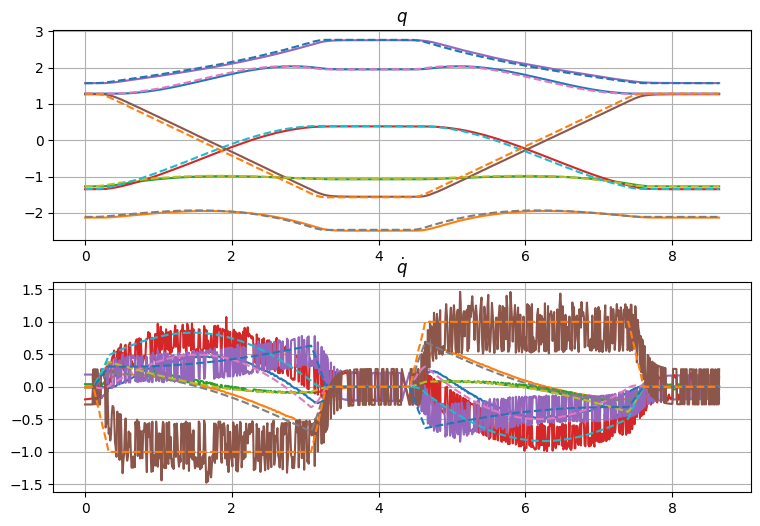

In [38]:
fig, ax = plt.subplots(2, 1, num=1, figsize=(9, 6))
ax[0].plot(tt[:it], qt[:it], "-")
ax[0].plot(tt[:it], rqt[:it], "--")
ax[0].grid()
ax[0].set_title("$q$")
ax[1].plot(tt[:it], qdt[:it], "-")
ax[1].plot(tt[:it], rqdt[:it], "--")
ax[1].grid()
ax[1].set_title("$\\dot q$")


Save data to Matlab MAT file

In [39]:
scipy.io.savemat("assets/inspection_results.mat", {"tt": tt, "qt": qt, "qdt": qdt, "xt": xt, "vt": vt, "rxt": rxt, "rvt": rvt, "rqt": rqt, "rqdt": rqdt, "mt": mt, "q": r.q, "rq": r.q_ref})

To see how to generate figures and videos, see "tutorial_image_video_pymujoco".